# Post EDA - Further Data Cleaning

This notebook contains the cleaning steps and updated top-20 correlation analysis moved from the post-EDA workflow. 

Based on the results of our EDA, we finalized the dataset by removing features that could introduce data leakage, redundancy, or limited predictive value.

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

new_df = pd.read_csv("MSE446_cleaned_dataset.csv")


## Analysis of EDA & Further Data Cleaning

Based on the results of our EDA, we will finalize our dataset before we begin modelling.

The ttm_ and l90d_ features represent historical pricing and performance metrics and are directly derived from pricing and booking outcomes, making them highly correlated with the target variable (rate_avg).

Including these features would introduce data leakage, as they contain information that would not be available when setting a price for a listing. 

In [15]:
# Remove all columns that start with 'ttm_' or 'l90d_'
cols_to_drop = [col for col in new_df.columns if col.startswith("ttm_") or col.startswith("l90d_")]
new_df = new_df.drop(columns=cols_to_drop)

print("Dropped columns:")
print(cols_to_drop)

Dropped columns:
['ttm_revenue', 'ttm_revenue_native', 'ttm_avg_rate', 'ttm_avg_rate_native', 'ttm_occupancy', 'ttm_adjusted_occupancy', 'ttm_revpar', 'ttm_revpar_native', 'ttm_adjusted_revpar', 'ttm_adjusted_revpar_native', 'ttm_reserved_days', 'ttm_blocked_days', 'ttm_available_days', 'ttm_total_days', 'l90d_revenue', 'l90d_revenue_native', 'l90d_avg_rate', 'l90d_avg_rate_native', 'l90d_occupancy', 'l90d_adjusted_occupancy', 'l90d_revpar', 'l90d_revpar_native', 'l90d_adjusted_revpar', 'l90d_adjusted_revpar_native', 'l90d_reserved_days', 'l90d_blocked_days', 'l90d_available_days', 'l90d_total_days']


During EDA, a clear outlier we identfied was a listing with 8 beds, which had very low prices. These extreme values could disproportionately influence model training and distort relationships between listing size and price. To improve model stability and reduce the impact of outliers, these observations were removed.

In [16]:
# Remove rows where beds = 8
new_df = new_df[new_df["beds"] != 8]

print("New shape after removing beds=8:")
print(new_df.shape)
print(new_df["beds"].value_counts())

New shape after removing beds=8:
(3225, 96)
beds
1    1876
2     759
3     282
4     187
5      66
0      44
6      11
Name: count, dtype: int64


Additional columns were removed based on their lack of relevance or predictive usefulness:

listing_id was removed as it is simply an identifier and does not provide meaningful information for our prediction.

Seasonal indicator variables (e.g., nba_season, nhl_season, mlb_season) were removed due to their limited variation and weak relationship with price observed during EDA.

Detailed weather variables (e.g., dew point, humidity, wind speed, precipitation components) were removed to reduce redundancy and noise, as these variables showed minimal impact on pricing and were highly correlated with each other.

The variables revenue, occupancy, and reserved_days were removed as they represent outcomes of pricing decisions rather than independent predictors.

These variables are determined after a listing is priced and booked, meaning they are influenced by the target variable itself. Including them would introduce data leakage and could lead to overly optimistic model performance.

To ensure the model reflects a realistic pricing scenario, only features available prior to pricing were retained.

In [17]:
# Remove additional ID, date, season, and weather columns
extra_cols_to_remove = [
    "listing_id", "date", "nba_season", "nhl_season", "mlb_season",
    "max_dew_point_v", "max_relative_humidity_v", "max_temperature_s", "max_wind_speed_v",
    "min_dew_point_v", "min_relative_humidity_v", "min_temperature_s", "min_wind_speed_v",
    "precipitation_v", "precipitation_s", "rain_v", "rain_s", "snow_v", "snow_s",
    "snow_on_ground_v", "revenue", "occupancy", "reserved_days", "vacant_days"
]

existing_extra_cols = [col for col in extra_cols_to_remove if col in new_df.columns]
missing_extra_cols = [col for col in extra_cols_to_remove if col not in new_df.columns]

new_df = new_df.drop(columns=existing_extra_cols)

print("Dropped extra columns:")
print(existing_extra_cols)

if missing_extra_cols:
    print("\nColumns not found (already absent):")
    print(missing_extra_cols)

print("\nShape after extra column removal:")
print(new_df.shape)

Dropped extra columns:
['listing_id', 'date', 'nba_season', 'nhl_season', 'mlb_season', 'max_dew_point_v', 'max_relative_humidity_v', 'max_temperature_s', 'max_wind_speed_v', 'min_dew_point_v', 'min_relative_humidity_v', 'min_temperature_s', 'min_wind_speed_v', 'precipitation_v', 'precipitation_s', 'rain_v', 'rain_s', 'snow_v', 'snow_s', 'snow_on_ground_v', 'revenue', 'occupancy', 'reserved_days', 'vacant_days']

Shape after extra column removal:
(3225, 72)


The minimum and maximum temperature variables were combined into a single avg_temp feature to simplify the representation of weather conditions.

This reduces redundancy while still capturing overall temperature trends, making the dataset more efficient and interpretable for modelling.

In [18]:
# Create average temperature and remove source temperature columns
temp_cols = ["min_temperature_v", "max_temperature_v"]

if all(col in new_df.columns for col in temp_cols):
    new_df["avg_temp"] = (new_df["min_temperature_v"] + new_df["max_temperature_v"]) / 2
    new_df = new_df.drop(columns=temp_cols)
    print("Created 'avg_temp' and dropped min_temperature_v, max_temperature_v")
else:
    missing_temp_cols = [col for col in temp_cols if col not in new_df.columns]
    print("Could not create avg_temp. Missing columns:")
    print(missing_temp_cols)

print("Current shape:")
print(new_df.shape)

Created 'avg_temp' and dropped min_temperature_v, max_temperature_v
Current shape:
(3225, 71)


After cleaning, a final correlation analysis was performed to identify the most relevant remaining features.

The results confirm that listing size attributes (e.g., bedrooms, guests, baths, beds) remain the strongest predictors of price, while other features such as amenities and location contribute to a lesser extent.

This step validates that the dataset is now well-structured and suitable for model training.

Top 20 remaining features by |correlation| with rate_avg:
['bedrooms', 'guests', 'baths', 'beds', 'listing_type_Entire home', 'cleaning_fee', 'room_type_private_room', 'photos_count', 'min_nights', 'listing_type_Private room in home', 'has_free_parking', 'cancellation_policy_Moderate', 'latitude', 'listing_type_Private room in rental unit', 'rating_location', 'listing_type_Entire guest suite', 'listing_type_Entire rental unit', 'rating_overall', 'listing_type_Private room in condo', 'listing_type_Entire loft']


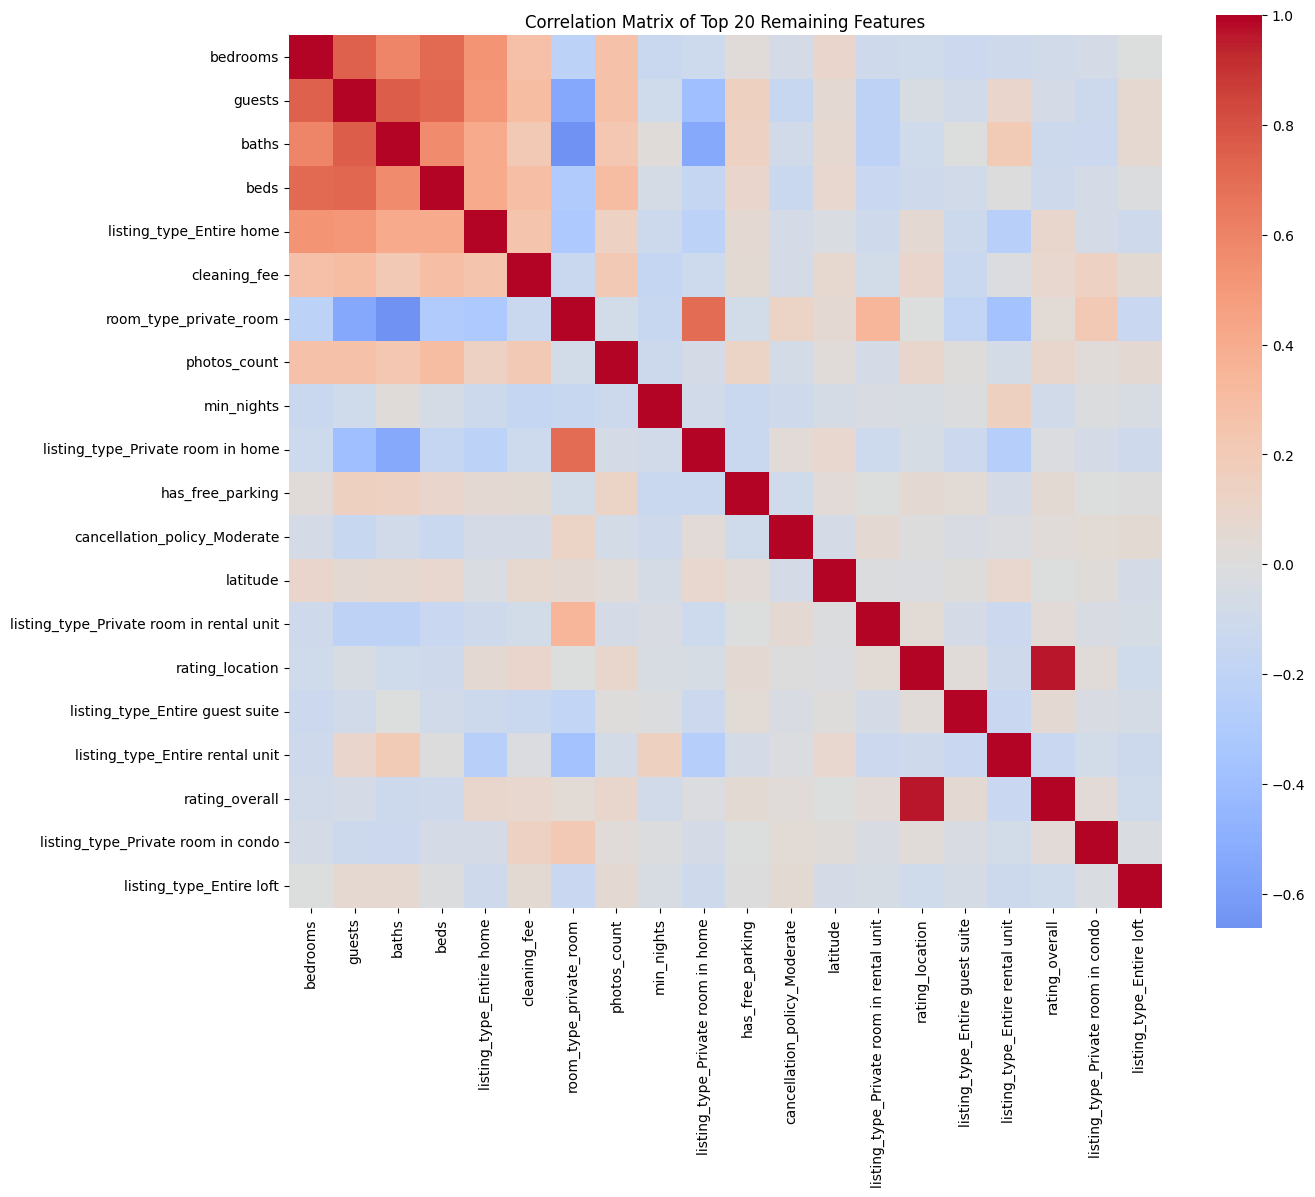

In [19]:
# Correlation matrix for top 20 remaining features
numeric_df = new_df.select_dtypes(include="number").copy()
corr_with_target = numeric_df.corr()["rate_avg"].abs().sort_values(ascending=False)
top_20_features = corr_with_target.drop("rate_avg").head(20).index.tolist()

print("Top 20 remaining features by |correlation| with rate_avg:")
print(top_20_features)

top_corr_matrix = numeric_df[top_20_features].corr()
plt.figure(figsize=(14, 12))
sns.heatmap(top_corr_matrix, cmap="coolwarm", center=0, square=True, annot=False)
plt.title("Correlation Matrix of Top 20 Remaining Features")
plt.tight_layout()
plt.show()

In [20]:
print(new_df.shape)

(3225, 71)


In [21]:
# Export cleaned dataframe to CSV
new_df.to_csv("MSE446_cleaned_dataset_postEDA.csv", index=False)